# Example I: Search problem 

## 1. Problem Introduction

Modern warehouses are increasingly adopting autonomous robotic systems to improve the efficiency, speed, and reliability of material handling and order fulfilment. Technologies such as Autonomous Mobile Robots (AMRs), Automated Guided Vehicles (AGVs), and Goods-to-Person (G2P) systems are used to transport products, shelves, bins, and other materials throughout warehouse environments. These systems reduce the need for workers to manually travel long distances across large warehouse facilities and can help streamline the movement of goods from storage areas to picking and packing stations.

Unlike traditional fixed-path systems, many modern autonomous warehouse robots use sensors, maps, and navigation algorithms to understand their surroundings, avoid obstacles, and determine suitable paths to their destinations. For example, in a G2P system, a robot may navigate through a warehouse, locate a required storage shelf or bin, and transport it directly to a stationary human worker at a picking station. As warehouses become larger and more complex, determining an efficient route for these robots becomes increasingly important.

The problem considered in this project is therefore a warehouse robot path-planning and route optimisation problem. An autonomous warehouse robot must navigate from a designated starting or loading area to a product-picking station or required product location within a simplified warehouse layout. The warehouse can be represented as a network of connected locations, where different routes may have different travel costs based on factors such as distance, time, energy consumption, congestion, or other operational considerations.

The primary objective is to determine a minimum-cost route between the robot's starting location and its required destination. Rather than simply finding any feasible path, the system aims to identify the most efficient route while considering the costs associated with travelling through different sections of the warehouse.

By modelling the warehouse as a graph and applying appropriate path-finding and optimisation techniques, we aim to investigate how autonomous warehouse robots can efficiently determine their routes. Finding effective solutions to this problem can help reduce unnecessary travel, lower operational costs, improve delivery and picking times, and ultimately contribute to more efficient and scalable autonomous warehouse operations.

## 2. Problem Definition

### Problem Definition

Finding an efficient route for an autonomous warehouse robot through a warehouse environment is a fundamental **path-planning and optimisation problem** in operations research and logistics. In this project, the warehouse is represented as a simplified graph consisting of locations (nodes) and connecting routes (edges), with each route assigned a travel cost. The robot must navigate from a designated starting point to a specific product or picking location while avoiding unnecessary travel and minimising the total cost of the journey.

The problem can be formulated as a **minimum-cost path-finding problem**, where the objective is to determine the least-cost sequence of routes connecting the robot's starting location to its required destination. This provides a simplified representation of the navigation challenges faced by autonomous warehouse systems such as AMRs, AGVs, and G2P robots.

To investigate this problem, the project focuses on two fundamental artificial intelligence search techniques: **Uniform Cost Search (UCS)** and **A* Search**. UCS determines the optimal path by expanding the lowest-cost path discovered so far, while A* combines the cost already incurred with a heuristic estimate of the remaining cost to guide the search towards the destination.

Therefore, the central research question of this project is:

> **How effectively can Uniform Cost Search and A* Search determine a minimum-cost navigation path for an autonomous warehouse robot, and which technique provides a better balance between solution cost and search efficiency?*

The performance of the two approaches will be evaluated based on factors such as **path cost, search efficiency, number of nodes explored, and computational effort**. This comparison will provide insight into the trade-off between guaranteeing an optimal solution and efficiently navigating the search space in an autonomous warehouse environment.


## 3. Warehouse State-Space Design

[Reference of warehouse layout](https://www.researchgate.net/figure/Graph-representation-of-the-warehouse_fig8_374910922)

![Base layout](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQig8wD86vGIufgkNhsFv-usHG1jaUkFhSPQt7boS_9lG7z15wzjZEGn9v9&s=10)

![Example layout](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTi-50Vx_JW3G_bH_HqaatqcaeKFTKB0_b9bEqPQmz8aQ&s=10)

### 3.1 Simplied layout

for this simplified layout we will be using:

- 5 vertical aisles
- 4 horizontal cross-aisles
- 20 major intersection states
- 1 starting location
- 1 destination
- All connections are weighted
- some higher-cost/congested sections

-------------------

In [1]:
# Import the libraries required to construct, visualise and search
# the weighted warehouse state-space graph.

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import heapq
import time

In [2]:
# Each state is assigned a coordinate so that A* can estimate
# the remaining distance to the goal.

cities = {
    'S': (-4, 12),

    'A1': (0, 12),
    'B1': (4, 12),
    'C1': (8, 12),
    'D1': (12, 12),
    'E1': (16, 12),

    'A2': (0, 8),
    'B2': (4, 8),
    'C2': (8, 8),
    'D2': (12, 8),
    'E2': (16, 8),

    'A3': (0, 4),
    'B3': (4, 4),
    'C3': (8, 4),
    'D3': (12, 4),
    'E3': (16, 4),

    'A4': (0, 0),
    'B4': (4, 0),
    'C4': (8, 0),
    'D4': (12, 0),
    'E4': (16, 0),

    'G': (16, -4)
}

In [3]:
G = nx.Graph()

# Add nodes and their coordinates
G.add_nodes_from(cities.keys())

# Add weighted edges
warehouse_edges = [
    ('S', 'A1', 4),

    ('A1', 'B1', 4),
    ('B1', 'C1', 4),
    ('C1', 'D1', 4),
    ('D1', 'E1', 4),

    ('A1', 'A2', 4),
    ('B1', 'B2', 4),
    ('C1', 'C2', 4),
    ('D1', 'D2', 4),
    ('E1', 'E2', 4),

    ('A2', 'B2', 4),
    ('B2', 'C2', 4),
    ('C2', 'D2', 4),
    ('D2', 'E2', 4),

    ('A2', 'A3', 4),
    ('B2', 'B3', 4),
    ('C2', 'C3', 4),
    ('D2', 'D3', 4),
    ('E2', 'E3', 4),

    ('A3', 'B3', 4),
    ('B3', 'C3', 4),
    ('C3', 'D3', 4),
    ('D3', 'E3', 4),

    ('A3', 'A4', 4),
    ('B3', 'B4', 4),
    ('C3', 'C4', 4),
    ('D3', 'D4', 4),
    ('E3', 'E4', 4),

    ('A4', 'B4', 4),
    ('B4', 'C4', 4),
    ('C4', 'D4', 4),
    ('D4', 'E4', 4),

    ('E4', 'G', 4)
]

G.add_weighted_edges_from(warehouse_edges)

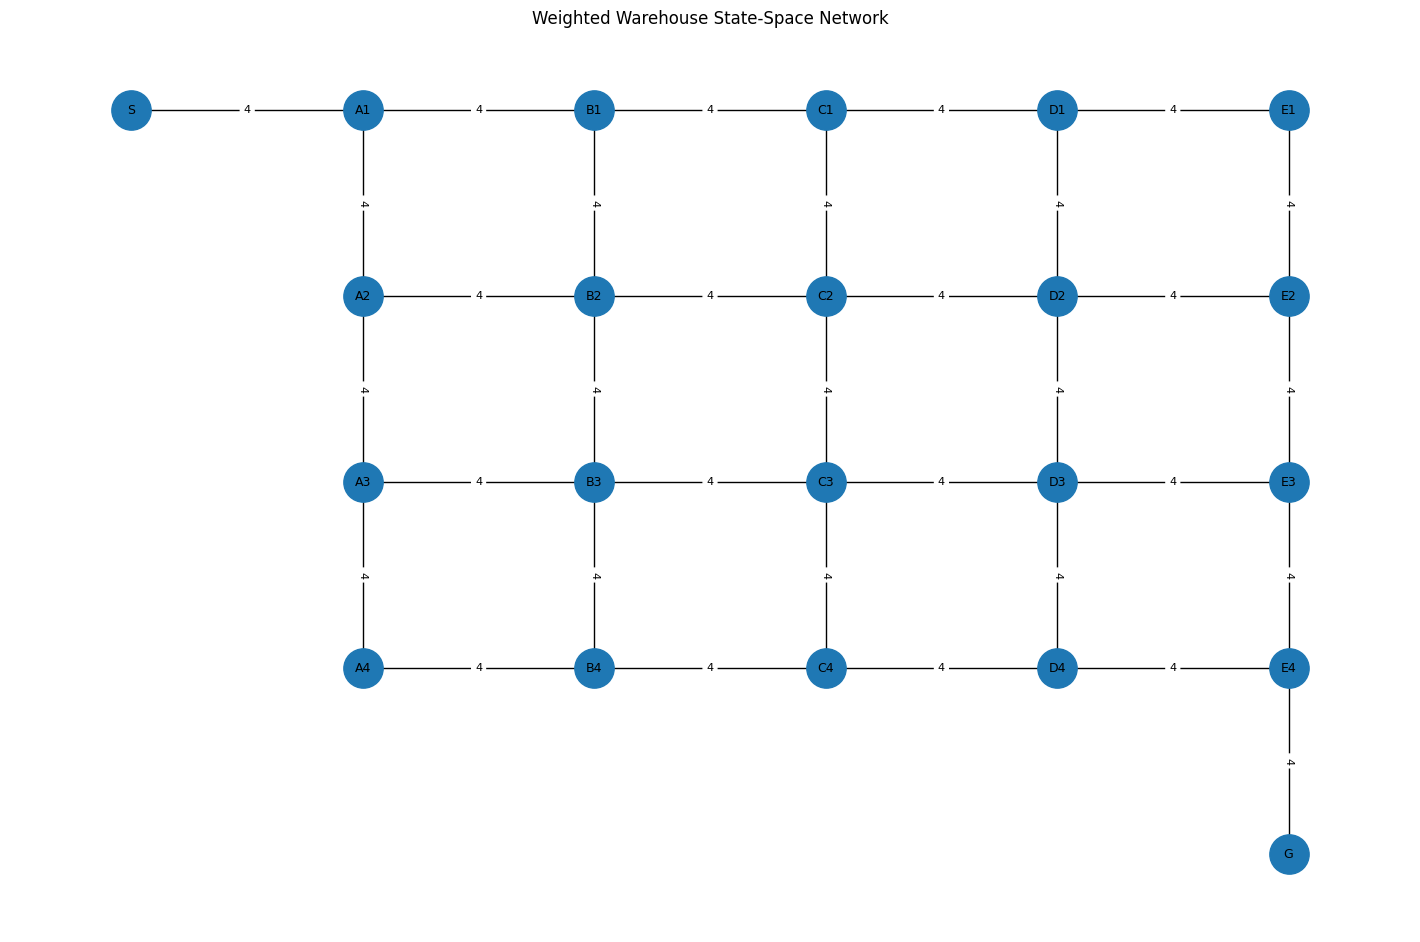

In [4]:
plt.figure(figsize=(14, 9))

nx.draw(
    G,
    cities,
    with_labels=True,
    node_size=800,
    font_size=9
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    cities,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Weighted Warehouse State-Space Network")
plt.axis("off")
plt.show()

In [5]:
print("Number of states:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of states: 22
Number of edges: 33


In [10]:
# Define the initial state and the destination state
# for the warehouse navigation problem.

source = 'S'
goal = 'G'

print('The start state is: {}'.format(source))
print('The goal state is: {}'.format(goal))

print("\nStates:")
print(list(G.nodes))

print("\nEdges:")
for u, v, data in G.edges(data=True):
    print(f"{u} -> {v}: cost = {data['weight']}")

The start state is: S
The goal state is: G

States:
['S', 'A1', 'B1', 'C1', 'D1', 'E1', 'A2', 'B2', 'C2', 'D2', 'E2', 'A3', 'B3', 'C3', 'D3', 'E3', 'A4', 'B4', 'C4', 'D4', 'E4', 'G']

Edges:
S -> A1: cost = 4
A1 -> B1: cost = 4
A1 -> A2: cost = 4
B1 -> C1: cost = 4
B1 -> B2: cost = 4
C1 -> D1: cost = 4
C1 -> C2: cost = 4
D1 -> E1: cost = 4
D1 -> D2: cost = 4
E1 -> E2: cost = 4
A2 -> B2: cost = 4
A2 -> A3: cost = 4
B2 -> C2: cost = 4
B2 -> B3: cost = 4
C2 -> D2: cost = 4
C2 -> C3: cost = 4
D2 -> E2: cost = 4
D2 -> D3: cost = 4
E2 -> E3: cost = 4
A3 -> B3: cost = 4
A3 -> A4: cost = 4
B3 -> C3: cost = 4
B3 -> B4: cost = 4
C3 -> D3: cost = 4
C3 -> C4: cost = 4
D3 -> E3: cost = 4
D3 -> D4: cost = 4
E3 -> E4: cost = 4
A4 -> B4: cost = 4
B4 -> C4: cost = 4
C4 -> D4: cost = 4
D4 -> E4: cost = 4
E4 -> G: cost = 4


### Euclidean heuristic

In [11]:
# Calculate the straight-line distance between two warehouse states.
# This is used by A* to estimate the remaining cost to the goal.

def heuristic(u, v):
    return np.sqrt(
        sum((x - y) ** 2 for x, y in zip(u, v))
    )

In [12]:
print("Heuristic from S to G:",
      heuristic(cities[source], cities[goal]))

Heuristic from S to G: 25.612496949731394


-------------------

### Priority Queue

In [13]:
# A priority queue is used as the frontier.
# Items with the lowest priority value are removed first.

class PriorityQueue:

    def __init__(self):
        self._heap = []

    def push(self, item, priority):
        heapq.heappush(self._heap, (priority, item))

    def pop(self):
        if self.is_empty():
            raise IndexError("pop from an empty priority queue")

        return heapq.heappop(self._heap)[1]

    def peek(self):
        if self.is_empty():
            raise IndexError("peek from an empty priority queue")

        return self._heap[0][1]

    def is_empty(self):
        return len(self._heap) == 0

    def __len__(self):
        return len(self._heap)

    def returnItems(self):
        return [item for _, item in self._heap]

    def returnElements(self):
        return [
            (priority, item)
            for priority, item in self._heap
        ]

## 4. UCS

In [14]:
def ucs_path(G, start, goal):
    """
    Find a minimum-cost path from start to goal
    using Uniform Cost Search.
    """

    print("Start node:", start)

    # The frontier is a priority queue.
    # UCS gives priority to the path with the smallest
    # accumulated cost.
    pq = PriorityQueue()

    # Each frontier item contains:
    # (current node, path taken so far, path cost)
    pq.push((start, [start], 0), 0)

    print("Initial frontier:")
    print(pq.returnElements())

    # Closed set records nodes that have already been expanded.
    visited = set()

    print("Initial closed set:", visited)

    # Store the best known cost to each node.
    best_cost = {start: 0}

    expansion_count = 0

    while pq:

        print("\nIteration:", expansion_count + 1)

        print(
            "Frontier before expansion:",
            pq.returnElements()
        )

        # Look at the node that will be expanded.
        print(
            "Node chosen to expand:",
            pq.peek()
        )

        # Remove the lowest-cost item.
        vertex, path, path_cost = pq.pop()

        # Ignore an outdated higher-cost entry.
        if path_cost > best_cost.get(vertex, float('inf')):
            continue

        expansion_count += 1

        print("Expanding:", vertex)

        # Add the expanded node to the closed set.
        visited.add(vertex)

        print("Closed set:", visited)

        # Late goal check, following the lab structure.
        if vertex == goal:

            print(
                "\nGoal found."
            )

            print(
                "Number of node expansions:",
                expansion_count
            )

            return path, path_cost, expansion_count

        # Expand the current node.
        neighbours = list(G.neighbors(vertex))

        print(
            "Neighbours:",
            neighbours
        )

        for neighbour in neighbours:

            if neighbour in visited:
                continue

            edge_cost = G[vertex][neighbour]['weight']

            new_cost = path_cost + edge_cost

            # Only keep this route if it is cheaper
            # than the previously discovered route.
            if new_cost < best_cost.get(
                neighbour,
                float('inf')
            ):

                best_cost[neighbour] = new_cost

                new_path = path + [neighbour]

                pq.push(
                    (neighbour, new_path, new_cost),
                    new_cost
                )

                print(
                    "Added:",
                    neighbour,
                    "with cost:",
                    new_cost
                )

    return None, float('inf'), expansion_count

In [15]:
# Run Uniform Cost Search on the warehouse problem.

ucs_start_time = time.perf_counter()

ucs_result = ucs_path(
    G,
    source,
    goal
)

ucs_end_time = time.perf_counter()

ucs_path_result, ucs_cost, ucs_expansions = ucs_result

ucs_runtime = ucs_end_time - ucs_start_time

print("\n===== UCS RESULT =====")
print("Path:", ucs_path_result)
print("Path cost:", ucs_cost)
print("Node expansions:", ucs_expansions)
print("Runtime:", ucs_runtime)

Start node: S
Initial frontier:
[(0, ('S', ['S'], 0))]
Initial closed set: set()

Iteration: 1
Frontier before expansion: [(0, ('S', ['S'], 0))]
Node chosen to expand: ('S', ['S'], 0)
Expanding: S
Closed set: {'S'}
Neighbours: ['A1']
Added: A1 with cost: 4

Iteration: 2
Frontier before expansion: [(4, ('A1', ['S', 'A1'], 4))]
Node chosen to expand: ('A1', ['S', 'A1'], 4)
Expanding: A1
Closed set: {'S', 'A1'}
Neighbours: ['S', 'B1', 'A2']
Added: B1 with cost: 8
Added: A2 with cost: 8

Iteration: 3
Frontier before expansion: [(8, ('A2', ['S', 'A1', 'A2'], 8)), (8, ('B1', ['S', 'A1', 'B1'], 8))]
Node chosen to expand: ('A2', ['S', 'A1', 'A2'], 8)
Expanding: A2
Closed set: {'S', 'A1', 'A2'}
Neighbours: ['A1', 'B2', 'A3']
Added: B2 with cost: 12
Added: A3 with cost: 12

Iteration: 4
Frontier before expansion: [(8, ('B1', ['S', 'A1', 'B1'], 8)), (12, ('B2', ['S', 'A1', 'A2', 'B2'], 12)), (12, ('A3', ['S', 'A1', 'A2', 'A3'], 12))]
Node chosen to expand: ('B1', ['S', 'A1', 'B1'], 8)
Expanding:

## 5. A*

In [16]:
def astar_path(G, start, goal):
    """
    Find a minimum-cost path from start to goal
    using A* Search.
    """

    print("Start node:", start)

    pq = PriorityQueue()

    # g(n) = cost from start to current node
    # h(n) = estimated cost from current node to goal
    # f(n) = g(n) + h(n)

    start_h = heuristic(
        cities[start],
        cities[goal]
    )

    pq.push(
        (start, [start], 0),
        start_h
    )

    print("Initial frontier:")
    print(pq.returnElements())

    visited = set()

    print("Initial closed set:", visited)

    best_cost = {start: 0}

    expansion_count = 0

    while pq:

        print("\nIteration:", expansion_count + 1)

        print(
            "Frontier before expansion:",
            pq.returnElements()
        )

        print(
            "Node chosen to expand:",
            pq.peek()
        )

        vertex, path, path_cost = pq.pop()

        # Ignore an outdated entry.
        if path_cost > best_cost.get(
            vertex,
            float('inf')
        ):
            continue

        expansion_count += 1

        print("Expanding:", vertex)

        visited.add(vertex)

        print("Closed set:", visited)

        # Late goal check, consistent with the lab.
        if vertex == goal:

            print("\nGoal found.")

            print(
                "Number of node expansions:",
                expansion_count
            )

            return path, path_cost, expansion_count

        neighbours = list(G.neighbors(vertex))

        print(
            "Neighbours:",
            neighbours
        )

        for neighbour in neighbours:

            if neighbour in visited:
                continue

            edge_cost = G[vertex][neighbour]['weight']

            new_g = path_cost + edge_cost

            if new_g < best_cost.get(
                neighbour,
                float('inf')
            ):

                best_cost[neighbour] = new_g

                h = heuristic(
                    cities[neighbour],
                    cities[goal]
                )

                f = new_g + h

                new_path = path + [neighbour]

                pq.push(
                    (neighbour, new_path, new_g),
                    f
                )

                print(
                    "Added:",
                    neighbour,
                    "g =",
                    new_g,
                    "h =",
                    round(h, 2),
                    "f =",
                    round(f, 2)
                )

    return None, float('inf'), expansion_count

In [17]:
# Run A* Search on exactly the same warehouse environment.

astar_start_time = time.perf_counter()

astar_result = astar_path(
    G,
    source,
    goal
)

astar_end_time = time.perf_counter()

astar_path_result, astar_cost, astar_expansions = astar_result

astar_runtime = astar_end_time - astar_start_time

print("\n===== A* RESULT =====")
print("Path:", astar_path_result)
print("Path cost:", astar_cost)
print("Node expansions:", astar_expansions)
print("Runtime:", astar_runtime)

Start node: S
Initial frontier:
[(25.612496949731394, ('S', ['S'], 0))]
Initial closed set: set()

Iteration: 1
Frontier before expansion: [(25.612496949731394, ('S', ['S'], 0))]
Node chosen to expand: ('S', ['S'], 0)
Expanding: S
Closed set: {'S'}
Neighbours: ['A1']
Added: A1 g = 4 h = 22.63 f = 26.63

Iteration: 2
Frontier before expansion: [(26.627416997969522, ('A1', ['S', 'A1'], 4))]
Node chosen to expand: ('A1', ['S', 'A1'], 4)
Expanding: A1
Closed set: {'S', 'A1'}
Neighbours: ['S', 'B1', 'A2']
Added: B1 g = 8 h = 20.0 f = 28.0
Added: A2 g = 8 h = 20.0 f = 28.0

Iteration: 3
Frontier before expansion: [(28.0, ('A2', ['S', 'A1', 'A2'], 8)), (28.0, ('B1', ['S', 'A1', 'B1'], 8))]
Node chosen to expand: ('A2', ['S', 'A1', 'A2'], 8)
Expanding: A2
Closed set: {'S', 'A1', 'A2'}
Neighbours: ['A1', 'B2', 'A3']
Added: B2 g = 12 h = 16.97 f = 28.97
Added: A3 g = 12 h = 17.89 f = 29.89

Iteration: 4
Frontier before expansion: [(28.0, ('B1', ['S', 'A1', 'B1'], 8)), (28.97056274847714, ('B2', 

### Final path validation

In [18]:
def calculate_path_cost(G, path):
    """
    Calculate the total cost of a path by summing
    the weights of all edges in the path.
    """

    total_cost = 0

    for i in range(len(path) - 1):

        u = path[i]
        v = path[i + 1]

        total_cost += G[u][v]['weight']

    return total_cost

In [19]:
print(
    "UCS independently calculated cost:",
    calculate_path_cost(G, ucs_path_result)
)

print(
    "A* independently calculated cost:",
    calculate_path_cost(G, astar_path_result)
)

UCS independently calculated cost: 36
A* independently calculated cost: 36


## 6. Results

### Comparison Table

In [21]:
import pandas as pd

In [22]:
comparison = pd.DataFrame({
    "Metric": [
        "Path",
        "Path Cost",
        "Number of Node Expansions",
        "Execution Time",
        "Number of States in Path"
    ],

    "UCS": [
        ucs_path_result,
        ucs_cost,
        ucs_expansions,
        ucs_runtime,
        len(ucs_path_result)
    ],

    "A*": [
        astar_path_result,
        astar_cost,
        astar_expansions,
        astar_runtime,
        len(astar_path_result)
    ]
})

comparison

,Metric,UCS,A*
0,Path,"[S, A1, A2, A3, A4, B4, C4, D4, E4, G]","[S, A1, A2, B2, B3, C3, C4, D4, E4, G]"
1,Path Cost,36,36
2,Number of Node Expansions,22,22
3,Execution Time,0.001823,0.003025
4,Number of States in Path,10,10


### UCS path Visualization

In [23]:
def draw_solution(G, positions, path, title):
    """
    Display the warehouse graph and highlight
    the solution path produced by a search algorithm.
    """

    plt.figure(figsize=(14, 9))

    # Draw the complete warehouse graph.
    nx.draw(
        G,
        positions,
        with_labels=True,
        node_size=800,
        font_size=9
    )

    # Draw edge costs.
    edge_labels = nx.get_edge_attributes(
        G,
        'weight'
    )

    nx.draw_networkx_edge_labels(
        G,
        positions,
        edge_labels=edge_labels,
        font_size=8
    )

    # Convert the path into consecutive edges.
    path_edges = list(
        zip(path[:-1], path[1:])
    )

    # Highlight the solution route.
    nx.draw_networkx_edges(
        G,
        positions,
        edgelist=path_edges,
        width=4
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

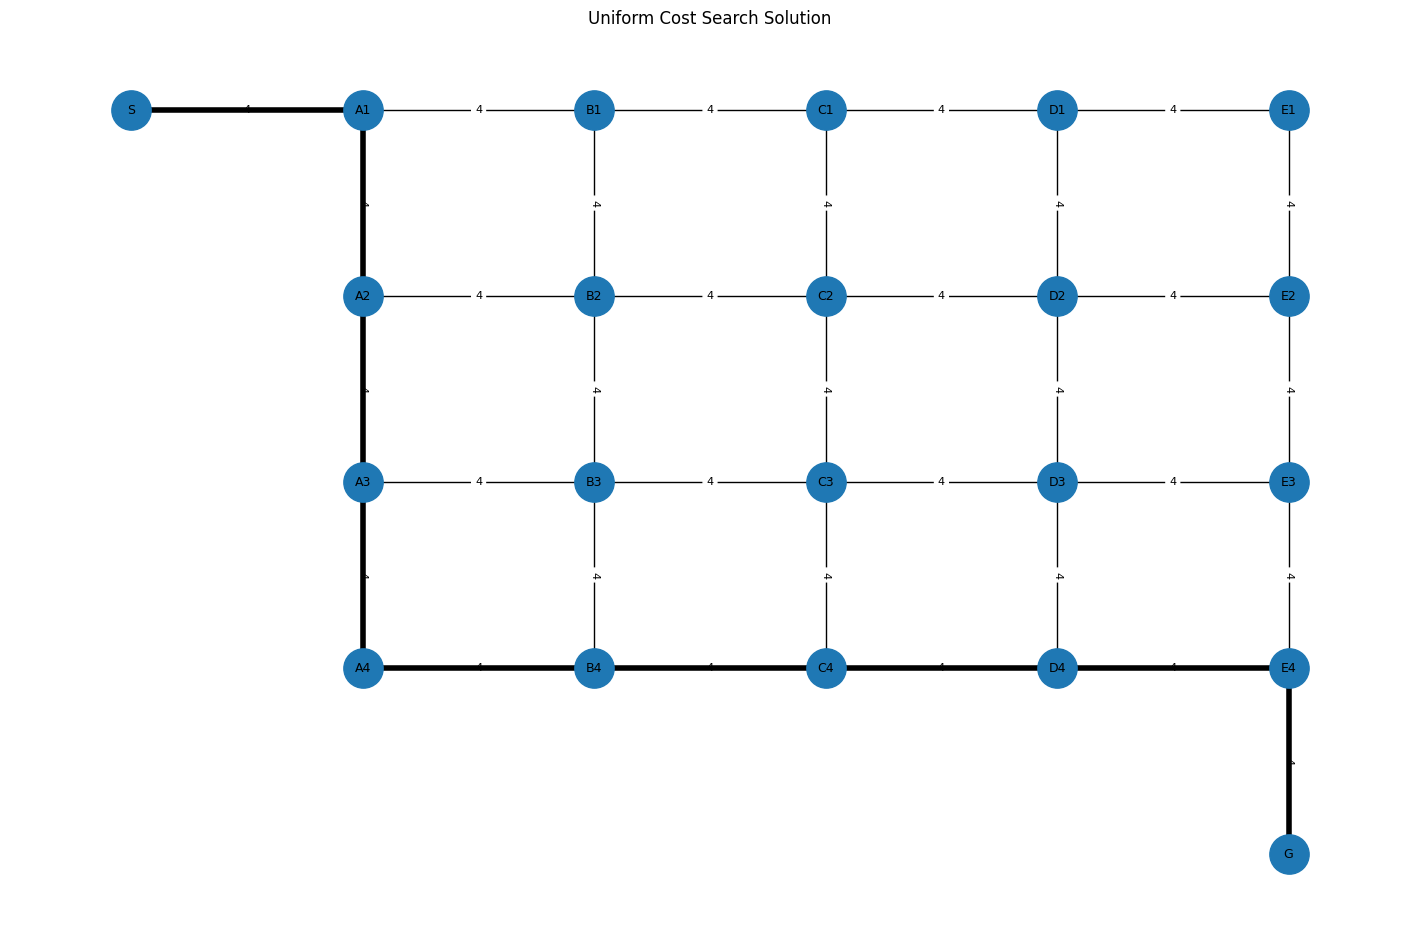

In [24]:
# UCS solution path visualization
draw_solution(
    G,
    cities,
    ucs_path_result,
    "Uniform Cost Search Solution"
)

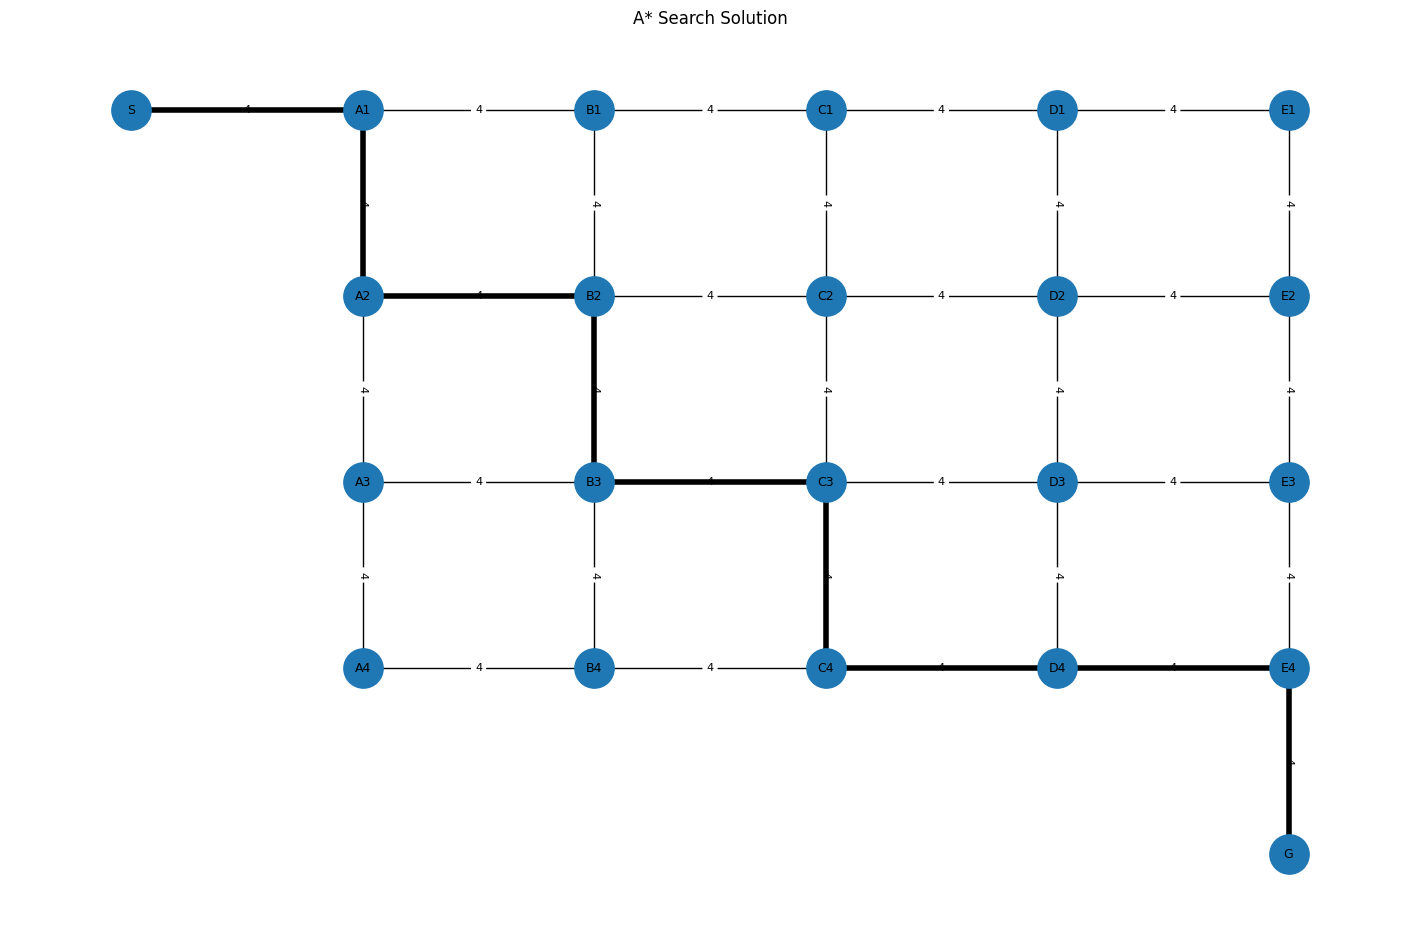

In [25]:
# A* solution path visualization
draw_solution(
    G,
    cities,
    astar_path_result,
    "A* Search Solution"
)

## 7. Comparison

### Path-cost comparison

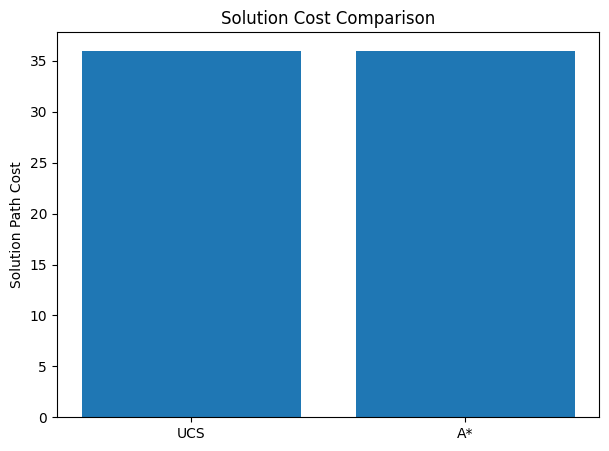

In [26]:
algorithms = ["UCS", "A*"]
path_costs = [ucs_cost, astar_cost]

plt.figure(figsize=(7, 5))

plt.bar(
    algorithms,
    path_costs
)

plt.ylabel("Solution Path Cost")
plt.title("Solution Cost Comparison")

plt.show()

### A* heuristic validation

In [27]:
def check_heuristic_consistency(G, coordinates, goal):
    """
    Check whether the Euclidean heuristic satisfies
    the consistency condition for every graph edge.
    """

    violations = []

    for u, v, data in G.edges(data=True):

        h_u = heuristic(
            coordinates[u],
            coordinates[goal]
        )

        h_v = heuristic(
            coordinates[v],
            coordinates[goal]
        )

        cost = data['weight']

        # Check h(u) <= c(u,v) + h(v)
        if h_u > cost + h_v + 1e-9:
            violations.append(
                (u, v, h_u, cost, h_v)
            )

        # Also check the reverse direction because
        # our warehouse graph is undirected.
        if h_v > cost + h_u + 1e-9:
            violations.append(
                (v, u, h_v, cost, h_u)
            )

    return violations

In [28]:
violations = check_heuristic_consistency(
    G,
    cities,
    goal
)

if len(violations) == 0:
    print(
        "The Euclidean heuristic satisfies the consistency "
        "condition for all warehouse edges."
    )
else:
    print("Consistency violations found:")
    for violation in violations:
        print(violation)

The Euclidean heuristic satisfies the consistency condition for all warehouse edges.
